In [1]:
from topological_insulator import Problem
import numpy as np
import sys
sys.path.append("/home/jlgpke/projects/UCL/research_project/topological_insulator/notebooks/project/")
from mean_field_problem import MeanFieldProblem

In [2]:
structure_path = "../../../../../topological_insulator/data/structures/"
structure_name = "kagome.json"

In [3]:
def _set_eigenvalues(problem:Problem, Delta_SOC, t, delta, U, occupations):
    sublattice_labels = ["A", "B", "C", "D", "E", "F"]
    cell = problem.cell_parser
    g = cell.geometry
    n_subs = len(g.delta_vectors.value)
    subs = sublattice_labels[:n_subs]
    for i, label_i in enumerate(subs):
        parser = getattr(problem.cell_parser.eigenvalues, label_i).value
        # Diagonal Values
        base = i * 8
        parser["chadi_soc"][label_i]["Delta_pp"] = Delta_SOC
        parser["interaction"][label_i]["U_p"] = U
        parser["interaction"][label_i]["n_px_up"] = occupations[2+base]
        parser["interaction"][label_i]["n_px_down"] = occupations[3+base]
        parser["interaction"][label_i]["n_py_up"] = occupations[4+base]
        parser["interaction"][label_i]["n_py_down"] = occupations[5+base]
        parser["interaction"][label_i]["n_pz_up"] = occupations[6+base]
        parser["interaction"][label_i]["n_pz_down"] = occupations[7+base]
        # Off-Diagonal Values
        for label_j in subs:
            # Hoppings
            try:
                parser["nn_hopping"][label_j]["t_pp_sigma"] = t - delta
                parser["nn_hopping"][label_j]["t_pp_pi"] = t + delta
            except:
                pass

In [4]:
location = "bulk"

In [ ]:
Delta_SOC = -5
t = -1

# Spin-Liquid Occupations

x1 = [1.        , 1.        , 0.41904251, 0.41904255, 0.48294694,
       0.482947  , 0.62099243, 0.62099234, 1.        , 1.        ,
       0.41904251, 0.41904255, 0.48294694, 0.482947  , 0.62099243,
       0.62099234, 1.        , 1.        , 0.50996218, 0.50996231,
       0.38906916, 0.38906922, 0.61818858, 0.61818846]

x2 = [1.        , 1.        , 0.41904251, 0.41904255, 0.48294694,
       0.482947  , 0.62099243, 0.62099234, 1.        , 1.        ,
       0.41904251, 0.41904255, 0.48294694, 0.482947  , 0.62099243,
       0.62099234, 1.        , 1.        , 0.50996218, 0.50996231,
       0.38906916, 0.38906922, 0.61818858, 0.61818846]

x3 = [1.        , 1.        , 0.58432352, 0.58432353, 0.63572526,
       0.63572528, 0.70758527, 0.70758523, 1.        , 1.        ,
       0.58432352, 0.58432353, 0.63572526, 0.63572528, 0.70758527,
       0.70758523, 1.        , 1.        , 0.66043496, 0.66043498,
       0.55902076, 0.55902078, 0.70698765, 0.70698761]

x4 = [1.        , 1.        , 0.45220403, 0.45220409, 0.50088856,
       0.50088864, 0.5638325 , 0.56383234, 1.        , 1.        ,
       0.45220403, 0.45220409, 0.50088856, 0.50088864, 0.5638325 ,
       0.56383234, 1.        , 1.        , 0.52424108, 0.52424116,
       0.4302341 , 0.43023416, 0.56376297, 0.56376282]

cases = {
    0: {"delta": 0.832, "U": 1, "x":x1}, # mu = 4.49
    1: {"delta": 0.832, "U": 3, "x":x2}, # mu = 1.44
#     2: {"delta": 0.25, "U": 0.6, "x": x3}, # mu = 5.06
#     3: {"delta": 0.25, "U": 1, "x": x4} # mu = 4.49
}

In [6]:
results = {}
for n, U_dict in enumerate(cases.values()):
    delta = U_dict["delta"]
    U = U_dict["U"]
    x = U_dict["x"]
    print("")
    print(f"Running case for: delta/t_1 = {delta/t}, and U/t = {U/t}")
    problem = Problem(structure_path=structure_path, structure_name=structure_name)
    _set_eigenvalues(problem, Delta_SOC, t, delta, U, x)
    problem.setup(
        N_r = 10,
        N_k = 400,
        location = location,
        BZ = "reduced"
    )
    problem.run(
        H_type="reciprocal"
    )
    results[n] = problem


Running case for: delta/t_1 = -0.832, and U/t = -1.0
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!

Running case for: delta/t_1 = -0.832, and U/t = -3.0
Building Geometry...
Geometry - Done.
Building 'Bulk' Hamiltonian...
'Bulk' Hamiltonian - Done.
Calculating 'Bulk' Eigenvalues...
'Bulk' Eigenvalues - Done!


In [7]:
j_3_2 = [i for i in range(12, 23)]
bands = [22, 23]

In [8]:
mean_field_problem = MeanFieldProblem(
        structure_path, structure_name, Delta_SOC=-5,
        t=t, U=0, delta=0.823, occupations= np.zeros(16)
)

mean_field_problem.setup(7, -1, 0.05, T = 300, N_h = 2)

## Case 0

In [9]:
g = results[0].geometry
tb_bulk = results[0].hamiltonian[location]["tight_binding"]
invariants = results[0].hamiltonian[location]["topological_invariants"]

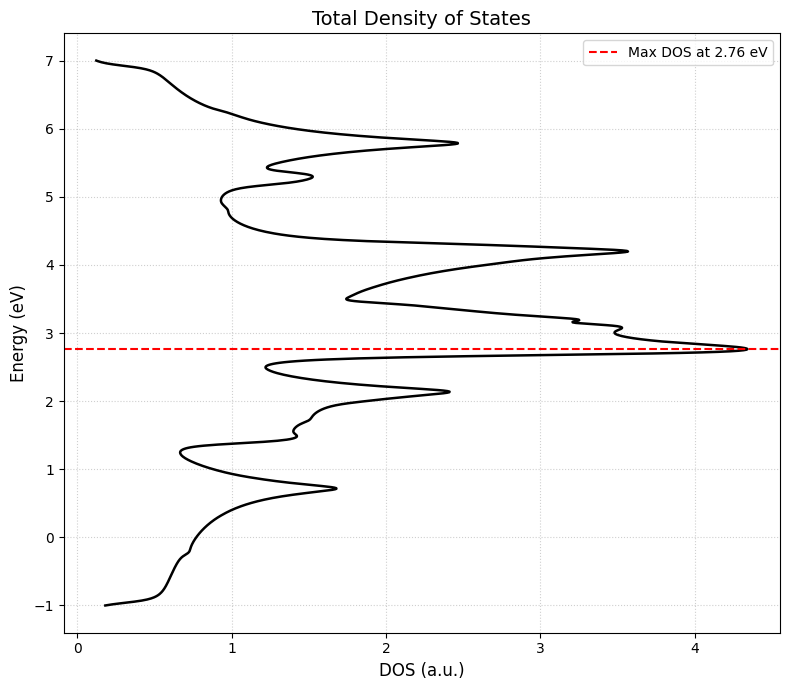

In [10]:
E, DOS = mean_field_problem.density_of_states(
    g, tb_bulk, invariants, mean_field_problem.E_max, 
    mean_field_problem.E_min, N_E=1000, eta=mean_field_problem.eta)
invariants.plot_density_of_states(E, DOS, xlabel="DOS")

In [11]:
from scipy.optimize import brentq

mu_max = np.max(E) +10
mu_min = np.min(E) -10
# print(mu_max, mu_min)
objective = lambda mu: mean_field_problem._estimate_N_h(E, DOS, mu, 300) - 2
mu, result = brentq(objective, mu_min, mu_max, full_output=True)
print(mu)

5.246603998020539


Calculating Z2 Invariant...
k=[0.0, 0.0]: delta = -1.0
k=[ 1.57079633 -0.90689968]: delta = -1.0
k=[0.         1.81379936]: delta = -1.0
k=[1.57079633 0.90689968]: delta = -1.0
Z2 Invariant - Done!
Z2 Invariant: 0
-0.1852346727883889


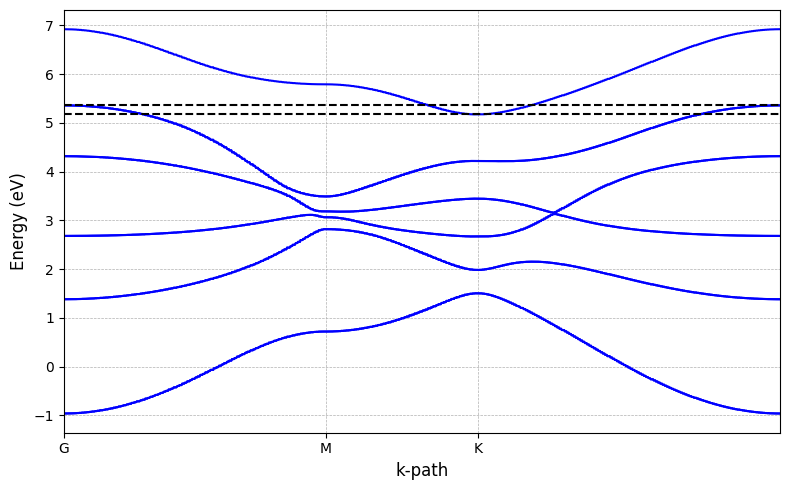

In [12]:
Z2 = invariants.Z2_invariant(bands, print_deltas=True)
print(f"Z2 Invariant: {Z2}")
dE, E_0, E_1 = invariants.get_band_gap(23, 21, only_dE=False)
print(dE)
tb_bulk.plot_band_structure(g, j_3_2, energies=[E_0, E_1])

In [13]:
# C, F = invariants.non_abelian_chern_invariant(bands=[22, 23])
# print(C)
# invariants.plot_berry_flux(F)

## Case 1

In [14]:
g = results[1].geometry
tb_bulk = results[1].hamiltonian[location]["tight_binding"]
invariants = results[1].hamiltonian[location]["topological_invariants"]

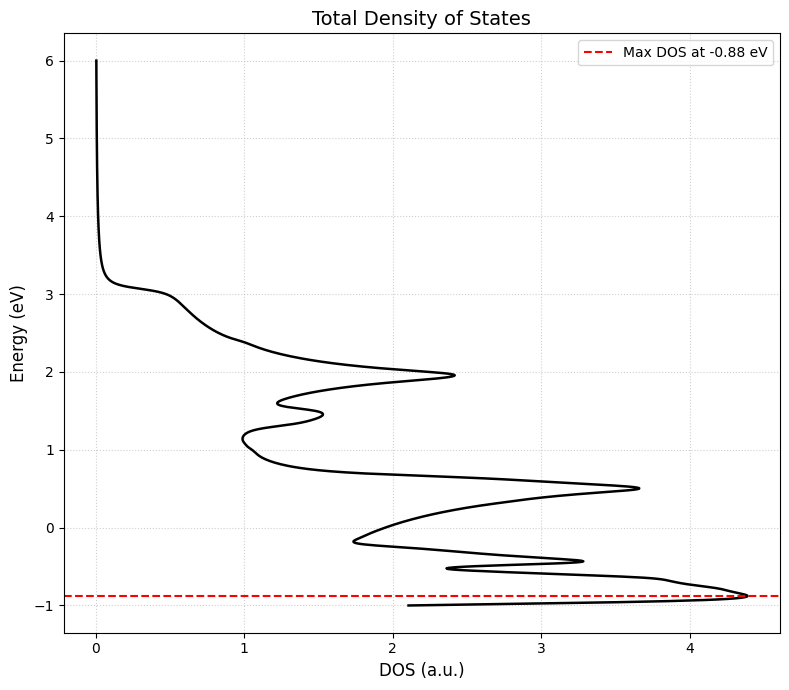

In [15]:
E, DOS = mean_field_problem.density_of_states(
    g, tb_bulk, invariants, 6, 
   -1, N_E=1000, eta=mean_field_problem.eta)
invariants.plot_density_of_states(E, DOS, xlabel="DOS")

In [16]:
mu_max = np.max(E) +10
mu_min = np.min(E) -10
# print(mu_max, mu_min)
objective = lambda mu: mean_field_problem._estimate_N_h(E, DOS, mu, 300) - 2
mu, result = brentq(objective, mu_min, mu_max, full_output=True)
print(mu)

1.4375810200525825


Calculating Z2 Invariant...
k=[0.0, 0.0]: delta = 1.0
k=[ 1.57079633 -0.90689968]: delta = 1.0
k=[0.         1.81379936]: delta = 1.0
k=[1.57079633 0.90689968]: delta = 1.0
Z2 Invariant - Done!
Z2 Invariant: 0
-0.2257784849187161


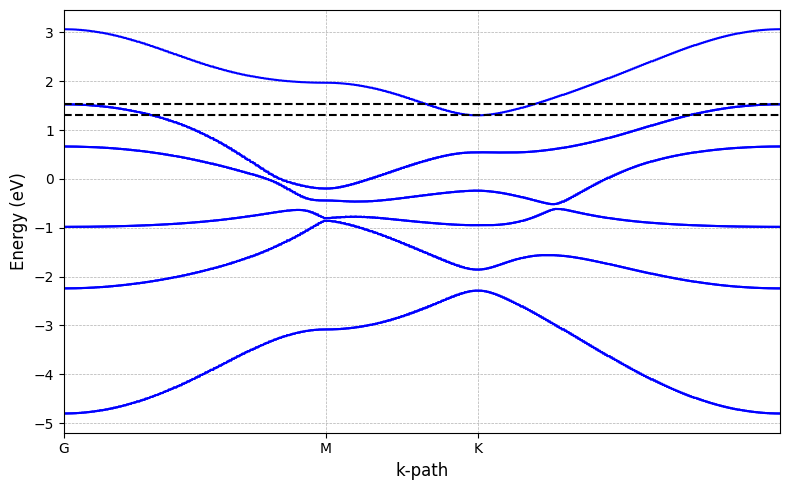

In [17]:
Z2 = invariants.Z2_invariant(bands, print_deltas=True)
print(f"Z2 Invariant: {Z2}")
dE, E_0, E_1 = invariants.get_band_gap(23, 21, only_dE=False)
print(dE)
tb_bulk.plot_band_structure(g, j_3_2,  energies=[E_0, E_1])

In [18]:
# C, F = invariants.non_abelian_chern_invariant(bands=[22, 23])
# print(C)
# invariants.plot_berry_flux(F)